In [ ]:
# pip install fake_useragent

In [ ]:
pip install -U selenium webdriver-manager

In [2]:
import requests
import json
from fake_useragent import UserAgent
import time
import pandas as pd
import numpy as np
import math
import locale
import datetime
import re
import os
from tqdm.auto import tqdm
from openai import OpenAI
import matplotlib.pyplot as plt

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

## 0. 相关方程

In [3]:
def start_browser(user_data_dir=None, headless=False):
    opts = Options()
    opts.binary_location = CHROME_BINARY

    if headless:
        opts.add_argument("--headless=new")

    opts.add_argument("--disable-blink-features=AutomationControlled")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")

    if user_data_dir:
        opts.add_argument(f"--user-data-dir={user_data_dir}")

    service = Service(ChromeDriverManager().install())
    return webdriver.Chrome(service=service, options=opts)

def cookies_to_header(driver):
    cookies = driver.get_cookies()
    return "; ".join(f"{c['name']}={c['value']}" for c in cookies)

def is_logged_in_weibo(driver) -> bool:
    """
    DOM/URL-based login detection (NOT cookie-based).
    Heuristics:
    - redirected to passport.weibo.com => not logged in
    - visible "登录" entry points => not logged in
    - visible user/home UI elements => logged in
    """
    url = (driver.current_url or "").lower()
    if "passport.weibo.com" in url:
        return False

    # Some common "not logged in" signals
    login_xpaths = [
        "//a[contains(@href,'passport.weibo.com') and (contains(.,'登录') or contains(.,'Log'))]",
        "//*[contains(text(),'登录') and (self::a or self::button)]",
        "//*[contains(text(),'扫码登录')]",
        "//*[contains(text(),'注册') and (self::a or self::button)]",
    ]
    for xp in login_xpaths:
        try:
            els = driver.find_elements(By.XPATH, xp)
            if any(e.is_displayed() for e in els):
                return False
        except Exception:
            pass

    # Some common "logged in" signals (header features vary; we use multiple)
    logged_in_xpaths = [
        "//*[contains(text(),'退出')]",                 # logout link sometimes exists
        "//*[contains(text(),'消息')]",                 # messages
        "//*[contains(text(),'发微博')]",               # post button
        "//a[contains(@href,'/u/')]",                   # profile link style
        "//a[contains(@href,'weibo.com/u/')]",          # profile link style
    ]
    for xp in logged_in_xpaths:
        try:
            els = driver.find_elements(By.XPATH, xp)
            if any(e.is_displayed() for e in els):
                return True
        except Exception:
            pass

    # Fallback: if neither found, treat as not logged in
    return False

def wait_for_weibo_login(driver, timeout_seconds=120, poll_seconds=2) -> bool:
    deadline = time.time() + timeout_seconds
    while time.time() < deadline:
        if is_logged_in_weibo(driver):
            return True
        time.sleep(poll_seconds)
    return False

def extract_status_id_from_textarea(driver, timeout=20) -> str:
    """
    Extract Weibo status ID from:
    <textarea id="comment-textarea-<STATUS_ID>">
    """

    # Wait until the comment textarea is present in the DOM
    textarea = WebDriverWait(driver, timeout).until(
        EC.presence_of_element_located(
            (By.XPATH, "//textarea[starts-with(@id, 'comment-textarea-')]")
        )
    )

    textarea_id = textarea.get_attribute("id")
    # e.g. "comment-textarea-5263307886035659"

    match = re.match(r"comment-textarea-(\d+)", textarea_id)
    if not match:
        raise RuntimeError(f"Unexpected textarea id format: {textarea_id}")

    return match.group(1)


def open_weibo_and_get_cookie(post_url: str, user_data_dir="./chrome_profile_weibo", timeout_seconds=120):
    driver = start_browser(user_data_dir=user_data_dir, headless=False)
    driver.get(post_url)

    print("====================================================")
    print("Weibo login required.")
    print("A Chrome window has opened.")
    print("Please log in to Weibo (QR code / username).")
    print(f"You have {timeout_seconds} seconds (2 minutes).")
    print("After login, come back here — the script will continue automatically.")
    print("====================================================")

    ok = wait_for_weibo_login(driver, timeout_seconds=timeout_seconds, poll_seconds=2)
    if not ok:
        driver.quit()
        raise RuntimeError("Login not detected within 2 minutes. Please rerun and log in first.")

    cookie_header = cookies_to_header(driver)
    status_id = extract_status_id_from_textarea(driver)

    return driver, cookie_header, status_id

In [4]:
# 获取所有微博评论方程
def fetch_all(COOKIE_HEADER, BASE, params, max_pages=30):
  ua = UserAgent().random
  s = requests.Session()
  s.headers.update({
      "User-Agent": ua,
      "Accept": "application/json, text/plain, */*",
      "Referer": "https://weibo.com/",
      "Cookie": COOKIE_HEADER,
      "Connection": "keep-alive",
  })

  # Warm up: looks more like a browser flow and can set/refresh session cookies
  s.get("https://weibo.com/", timeout=15)

  # If XSRF-TOKEN exists as a cookie, mirror it in header (often helps)
  xsrf = s.cookies.get("XSRF-TOKEN")
  if xsrf:
      s.headers["X-XSRF-TOKEN"] = xsrf

  out = []

  for page in range(1, max_pages + 1):
      r = s.get(BASE, params=params, timeout=15)
      r.raise_for_status()
      j = r.json()

      if j.get("ok") == -100:
          raise RuntimeError("Login required (ok:-100): cookies expired / incomplete / mismatched.")

      data = j.get("data", [])
      out.extend(data)

      next_max_id = j.get("max_id", 0)
      print(f"page={page} got={len(data)} next_max_id={next_max_id}")

      # stop if stream ends
      if not data or not next_max_id:
          break

      params["max_id"] = next_max_id
      time.sleep(1)  #每次访问后休眠一秒

  return out

In [9]:
def build_comments_df(comments):
    """
    comments: list of dicts returned by fetch_all (top-level comments)
    Returns: DataFrame with columns:
      - posted_time
      - comment
      - like_count
      - comment_type (primary/secondary)
    """
    rows = []

    for c in comments:
        # 1) primary comment
        rows.append({
            "posted_time": c.get("created_at"),
            "comment": c.get("text_raw"),
            "like_count": c.get("like_counts"),
            "comment_type": "primary",
        })

        # 2) secondary comments (if any)
        children = c.get("comments")
        if isinstance(children, list) and len(children) > 0:
            for cc in children:
                rows.append({
                    "posted_time": cc.get("created_at"),
                    "comment": cc.get("text_raw"),
                    "like_count": cc.get("like_counts"),
                    "comment_type": "secondary",
                })

    df = pd.DataFrame(rows)

    # format时间
    df['posted_time'] = pd.to_datetime(
        df["posted_time"],
        format="%a %b %d %H:%M:%S %z %Y",
        errors="raise"
    ).dt.tz_localize(None)

    return df.sort_values(by='posted_time', ascending=False).reset_index(drop=True)

In [8]:
# 情感分析方程
def deepseek_sentiment_3class(
    df: pd.DataFrame,
    rows_per_request: int,
    text_col: str = "comment",
    model: str = "deepseek-chat",
    max_retries: int = 5,
    sleep_base: float = 1.5,
) -> pd.DataFrame:
  texts = df[text_col].astype(str).fillna("").tolist()
  n = len(texts)

  labels = [None] * n
  confs  = [None] * n

  SYSTEM = """你是中文微博评论的情感分析器。
  你的任务是判断评论的整体情感倾向，只能输出以下三类之一：

  - POS：整体为正面（包括表扬、支持、送花、点赞、正向表情）
  - NEG：整体为负面（不满、批评、讽刺、抱怨）
  - MIXED：同时包含明显正面和负面，或态度矛盾

  规则：
  - 即使评论很短，只要语用上是支持或表扬，也可以判为 POS
  - 不要输出 NEU / UNKNOWN / 其他类别
  - 不要解释规则
  """

  for start in tqdm(range(0, n, rows_per_request), desc="DeepSeek sentiment (3-class)"):
      end = min(start + rows_per_request, n)
      batch = texts[start:end]

      payload = [{"i": start + j, "text": t} for j, t in enumerate(batch)]

      user_msg = (
          "请对以下评论逐条进行情感判断，只能输出严格 JSON。\n\n"
          "JSON 格式：\n"
          "{\n"
          '  "results": [\n'
          '    {"i": 0, "label": "POS|NEG|MIXED", "confidence": 0~1}, ...\n'
          "  ]\n"
          "}\n\n"
          f"评论列表：{json.dumps(payload, ensure_ascii=False)}"
      )

      for attempt in range(max_retries):
          try:
              resp = client.chat.completions.create(
                  model=model,
                  messages=[
                      {"role": "system", "content": SYSTEM},
                      {"role": "user", "content": user_msg},
                  ],
                  temperature=0,
                  response_format={"type": "json_object"},
              )

              data = json.loads(resp.choices[0].message.content)

              for r in data["results"]:
                  i = int(r["i"])
                  labels[i] = r["label"]
                  confs[i]  = float(r["confidence"])

              break

          except Exception:
              if attempt == max_retries - 1:
                  for i in range(start, end):
                      labels[i], confs[i] = "MIXED", 0.5
              else:
                  time.sleep(sleep_base * (2 ** attempt))

  return pd.DataFrame(
      {"sentiment": labels, "confidence": confs},
      index=df.index,
  )

In [7]:
#总结关键词方程
def summarize_keywords_with_examples(comments_df, n: int, model: str = "deepseek-chat"):
  comments = (
      comments_df.head(n)["comment"]
      .astype(str)
      .fillna("")
      .tolist()
  )

  SYSTEM = """你是中文社交媒体评论分析助手。
  任务：从给定评论中提炼最重要的3个关键词，并为每个关键词挑选3条最能代表该关键词的原始评论（逐字引用）。
  要求：
  - 只输出 JSON（不要输出任何额外文字）
  - keywords 必须恰好 3 个
  - 每个 keyword 的 supporting_comments 必须恰好 3 条，且必须来自输入评论原文（逐字）
  - summary 用中文，不超过两句话
  - 关键词要尽量是“主题/实体/概念词”，避免过于泛化（如“感觉”“东西”）
  """

  user_msg = (
      "请从以下评论中提炼关键词并给出例句。\n"
      "输出严格 JSON，格式必须为：\n"
      "{\n"
      '  "keywords": [\n'
      '    {"keyword": "xxx", "supporting_comments": ["原始评论1","原始评论2","原始评论3"]},\n'
      '    {"keyword": "yyy", "supporting_comments": ["...","...","..."]},\n'
      '    {"keyword": "zzz", "supporting_comments": ["...","...","..."]}\n'
      "  ],\n"
      '  "summary": "两句话以内"\n'
      "}\n\n"
      "注意：supporting_comments 必须逐字来自输入评论，不要改写。\n\n"
      f"评论列表：{json.dumps(comments, ensure_ascii=False)}"
  )

  resp = client.chat.completions.create(
      model=model,
      messages=[
          {"role": "system", "content": SYSTEM},
          {"role": "user", "content": user_msg},
      ],
      temperature=0,
      response_format={"type": "json_object"},
  )

  return json.loads(resp.choices[0].message.content)

In [6]:
# 画总结图方程
def plot_sentiment(ax, df, title, sentiment_col="sentiment"):
  order = ["POS", "NEG", "MIXED"]
  counts = df[sentiment_col].value_counts().reindex(order).fillna(0).astype(int)
  total = counts.sum()

  if total == 0:
      pct = counts * 0.0
  else:
      pct = counts / total * 100.0

  x = np.arange(len(order))
  bars = ax.bar(x, counts.values)

  ax.set_xticks(x, order)
  ax.set_ylabel("Count")
  ax.set_title(title)

  for rect, p in zip(bars, pct.values):
      h = rect.get_height()
      ax.text(
          rect.get_x() + rect.get_width() / 2,
          h,
          f"{p:.1f}%",
          ha="center",
          va="bottom"
      )

  ymax = max(counts.max(), 1)
  ax.set_ylim(0, ymax * 1.20)

## 1. 获取微博的所有评论

In [14]:
CHROME_BINARY = "/Applications/Google Chrome.app/Contents/MacOS/Google Chrome"
CHROME_BINARY = "C:/Program Files/Google/Chrome/Application"
post_url = "https://weibo.com/1742666164/QqyVupk9l"  # 唯一需要user input的地方
uid = post_url.rstrip("/").split("/")[-2]
driver, COOKIE_HEADER, status_id = open_weibo_and_get_cookie(post_url, timeout_seconds=120)

print("Cookie header length:", len(COOKIE_HEADER))
print("Extracted status_id:", status_id)
driver.quit()

SessionNotCreatedException: Message: session not created: Failed to create Chrome process.; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#sessionnotcreatedexception
Stacktrace:
Symbols not available. Dumping unresolved backtrace:
	0x965093
	0x9650d4
	0x75b490
	0x78fd55
	0x78bb00
	0x7d47bf
	0x7d3fd7
	0x7c7f56
	0x7996c9
	0x79a484
	0xbb7e34
	0xbb30c9
	0xbd0add
	0x97db38
	0x9858ad
	0x96d848
	0x96da12
	0x9575fa
	0x74a35d49
	0x76fad5db
	0x76fad561


从这里开始是需要多次跑的部分：

In [5]:
# Web scrap the post
BASE = "https://weibo.com/ajax/statuses/buildComments"

status_id = 5263307886035659
uid = 1742666164
COOKIE_HEADER = "SUB=_2AkMe0qxef8NxqwFRmvEczWrqZY5-wgzEieKojl2FJRMxHRl-yT9kqhEitRB6NVKCsUQHrlAXs4N352tBDflKxznsP4jI; SUBP=0033WrSXqPxfM72-Ws9jqgMF55529P9D9WWTQvifhzNFXMEiRDas5EKm"
params = {
    "flow": 1, # 0按热度，1按时间排序
    "is_reload": 1,
    "id": f"{status_id}",
    "is_show_bulletin": 2,
    "is_mix": 0,
    "count": 20,
    "uid": f"{uid}",
    "fetch_level": 0,
    "max_id": 0,
}

comments = fetch_all(COOKIE_HEADER=COOKIE_HEADER, BASE=BASE, params=params)
print("total comments returned (including repeats):", len(comments))

page=1 got=19 next_max_id=5263458876524743
page=2 got=19 next_max_id=5263387489471806
page=3 got=19 next_max_id=5263350686550028
page=4 got=18 next_max_id=5263334527471390
page=5 got=19 next_max_id=5263321072404828
page=6 got=20 next_max_id=5263317917505823
page=7 got=19 next_max_id=5263313143599171
page=8 got=17 next_max_id=0
total comments returned (including repeats): 150


In [10]:
# 获取raw comments
comments_df = build_comments_df(comments)
comments_df

,posted_time,comment,like_count,comment_type
0,2026-02-09 13:25:42,感谢邀请 期待更多合作,0,primary
1,2026-02-09 11:32:29,美景 美人 美物[期待],0,primary
2,2026-02-09 09:53:48,[鼓掌][鼓掌][鼓掌],0,primary
3,2026-02-08 19:23:46,哇哦,0,primary
4,2026-02-08 19:14:25,美,0,primary
...,...,...,...,...
166,2026-02-06 13:15:33,期待更多合作,48,primary
167,2026-02-06 13:15:29,谢谢邀请，常华森很帅[心],3,primary
168,2026-02-06 13:15:25,期待更多常华森合作[来抱抱][来抱抱],31,primary
169,2026-02-06 13:14:31,期待更多和华森的合作[拜托],33,primary


## 2. 用DeepSeek来判断评论好坏

In [11]:
# 这是我的个人API密钥，不可泄露
os.environ["DEEPSEEK_API_KEY"] = "sk-26e3bd6a00974081a25dc993e91f2a09"

client = OpenAI(
    api_key=os.environ["DEEPSEEK_API_KEY"],
    base_url="https://api.deepseek.com"
)

In [ ]:
# 让DeepSeek判断评论好坏
rows_per_request = 0

if comments_df.shape[0] < 50:
    rows_per_request = comments_df.shape[0]
else:
    rows_per_request = 50

evaled_df = deepseek_sentiment_3class(
    comments_df,
    text_col="comment",
    rows_per_request=rows_per_request,
)

df_final = comments_df.join(evaled_df)

DeepSeek sentiment (3-class):   0%|          | 0/4 [00:00<?, ?it/s]

In [16]:
df_final = comments_df.join(evaled_df)
df_final

,posted_time,comment,like_count,comment_type,sentiment,confidence
0,2026-02-09 13:25:42,感谢邀请 期待更多合作,0,primary,POS,0.95
1,2026-02-09 11:32:29,美景 美人 美物[期待],0,primary,POS,0.95
2,2026-02-09 09:53:48,[鼓掌][鼓掌][鼓掌],0,primary,POS,0.90
3,2026-02-08 19:23:46,哇哦,0,primary,POS,0.85
4,2026-02-08 19:14:25,美,0,primary,POS,0.85
...,...,...,...,...,...,...
166,2026-02-06 13:15:33,期待更多合作,48,primary,POS,0.90
167,2026-02-06 13:15:29,谢谢邀请，常华森很帅[心],3,primary,POS,0.95
168,2026-02-06 13:15:25,期待更多常华森合作[来抱抱][来抱抱],31,primary,POS,0.90
169,2026-02-06 13:14:31,期待更多和华森的合作[拜托],33,primary,POS,0.90


In [15]:
# 让DeepSeek给出近期评论的关键词/热词
keyword_result = summarize_keywords_with_examples(comments_df, n=rows_per_request)

## 3. 总结

### 3.1 近50条与所有评论好评占比

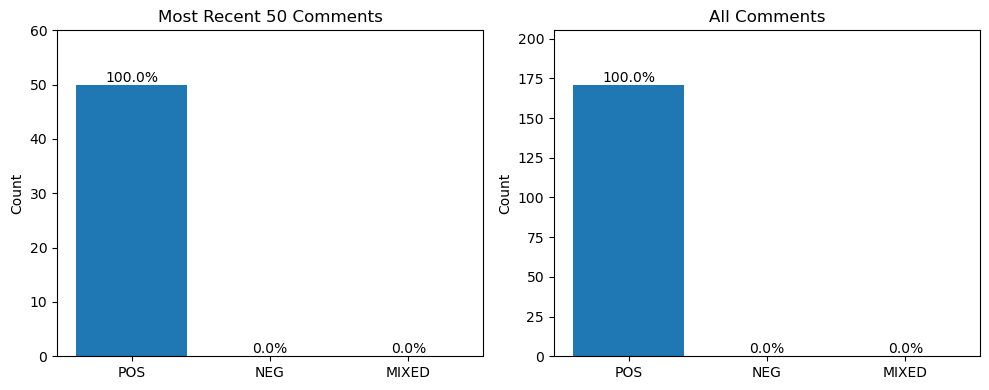

In [16]:
if rows_per_request < 50:
    plot_sentiment(
        axes[1],
        df_final,
        "All Comments"
    )
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
    
    plot_sentiment(
        axes[0],
        df_final.head(50),
        "Most Recent 50 Comments"
    )
    
    plot_sentiment(
        axes[1],
        df_final,
        "All Comments"
    )
    
    plt.tight_layout()
    plt.show()

### 3.2 重复出现的评论及其频率

In [17]:
dup_rows = df_final[df_final.duplicated(subset="comment", keep=False)]
dup_comment_summary = (
    dup_rows
    .groupby('comment', as_index=False)
    .agg(
        freq=('comment', 'size'),
        sentiment=('sentiment', 'first')
    )
).sort_values(by='freq', ascending=False)

dup_comment_summary

,comment,freq,sentiment
0,@兰蔻LANCOME,20,POS
9,感谢邀请,8,POS
2,[赢牛奶]感谢兰蔻邀请，期待常华森！,3,POS
6,感谢兰蔻邀请[求关注][求关注]期待以后更多合作～,3,POS
1,[求关注],2,POS
3,[送花花],2,POS
4,感谢兰蔻的邀请 期待未来能与常华森有更多的合作机会,2,POS
5,感谢兰蔻的邀请 期待未来能与常华森有更多的合作机会[给你小心心],2,POS
7,感谢兰蔻邀请，期待常华森！,2,POS
8,感谢兰蔻邀请，期待更多合作[爱慕],2,POS


### 3.3 近50条评论的关键信息总结：

In [18]:
for item in keyword_result["keywords"]:
    print("关键词:", item["keyword"])
    for c in item["supporting_comments"]:
        print("  -", c)

print("\n总结:", keyword_result["summary"])

关键词: 兰蔻
  - 感谢兰蔻邀请
  - 感谢@兰蔻LANCOME 邀请，期待更多合作
  - 感谢兰蔻的邀请 期待未来能与常华森有更多的合作机会[期待]
关键词: 常华森
  - @常华森 好帅，期待未来更多合作[打call]
  - 啊啊啊啊啊啊啊啊常华森
  - 常华森的脸果然适合高清观看[么么哒]
关键词: 合作
  - 感谢邀请 期待更多合作
  - 期待更多与常华森的合作[么么哒]
  - 会更加期待华森，与兰蔻在未来的合作[打call]

总结: 评论主要围绕兰蔻品牌邀请常华森合作展开，表达了感谢、期待和赞美之情。


# Pending Tasks:
1. 如何将url贴入软件
2. 能不能有那种探测新评论的功能（目前想法就是每次对比comments_df的长度）
3. dataframe dtype test